# Python Exercises - Part 3

Notion: https://app.notion.com/p/Ex-3-Python-Exercises-373622d60556805eb4f4df6869f1dd6a?source=copy_link

### 51. Cartesian Product of Two Sets

Write a program that finds the Cartesian product of two sets.


In [3]:
def cartesian_product(set1, set2):
    product = [(x, y) for x in set1 for y in set2]
    return product

In [4]:
A = input("Enter A: ").split(", ")
B = input("Enter B: ").split(", ")
# Convert to set
set1 = set(int(x) for x in A)
set2 = set(int(y) for y in B)

for x in cartesian_product(set1, set2):
    print(x)

Enter A: 1, 2, 3
Enter B: 1, 2, 3, 4, 5
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(1, 5)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(2, 5)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(3, 5)


### 52. Plane Equation Passing Through 3 Points

Write a program that determines the equation of a plane passing through three 3D points.


In [8]:
def get_normal_vector(a, b):
    n1 = (a[1] * b[2]) - (a[2] * b[1])
    n2 = (a[2] * b[0]) - (a[0] * b[2])
    n3 = (a[0] * b[1]) - (a[1] * b[0])
    N = [n1, n2, n3]
    return N

a1, a2, a3 = eval(input("Enter a1, a2, a3: "))
b1, b2, b3 = eval(input("Enter b1, b2, b3: "))
c1, c2, c3 = eval(input("Enter c1, c2, c3: "))

A = [int(a1), int(a2), int(a3)]
B = [int(b1), int(b2), int(b3)]
C = [int(c1), int(c2), int(c3)]

AB = [b1 - a1, b2 - a2, b3 - a3]
AC = [c1 - a1, c2 - a2, c3 - a3]

N = get_normal_vector(AB, AC)
print("Normal vector: ", N)

d = -(N[0] * A[0]) - (N[1] * A[1]) - (N[2] * A[2])
print("d:", d)

# Display the plane equation
print(f"Plane equation: {N[0]}x + {N[1]}y + {N[2]}z + {d} = 0")

Enter a1, a2, a3: 2, 0, -1
Enter b1, b2, b3: 1, -2, 3
Enter c1, c2, c3: 0, 1, 2
Normal vector:  [-10, -5, -5]
d: 15
Plane equation: -10x + -5y + -5z + 15 = 0


### 53. Emirp Numbers (1–1000)

Write a program that displays all emirp numbers between 1 and 1000.


In [12]:
def is_prime(number):
    divisor = 2
    while divisor <= number / 2:
        if number % divisor == 0:
            return False
        divisor += 1
    return True


def emirp(number):
    if is_prime(number) is True:
        original_number = number
        reverse_number = 0
        while number > 0:  # Reverse the number
            digit = number % 10
            reverse_number = (reverse_number * 10) + digit
            number = number // 10
        # The number is a emirp when its reverse is also a prime
        # Exclude the palindrome numbers
        if reverse_number != original_number and is_prime(reverse_number):
            return True

In [14]:
# Display as table with 10 numbers each line
number_of_lines = 10

for i in range(1, 1001):
    if emirp(i) is True:
        print(format(i, '5d'), end="")
        number_of_lines -= 1
    if number_of_lines == 0:
        print()
        number_of_lines = 10

   13   17   31   37   71   73   79   97  107  113
  149  157  167  179  199  311  337  347  359  389
  701  709  733  739  743  751  761  769  907  937
  941  953  967  971  983  991

### 54. Relation Properties in a Set

Determine whether a relation is reflexive, symmetric, antisymmetric, and transitive.


In [15]:
def get_all_order_pairs(set_items):
    n = len(set_items)
    order_pairs = set()
    for i in range(n):
        for j in range(n):
            order_pairs.add((int(set_items[i]), int(set_items[j])))
    return order_pairs

In [16]:
def get_sub_order_pairs(number, set_items):
    # Get subsets of ordered pairs by the user
    # and create the relation
    order_pair_sets = get_all_order_pairs(set_items)
    sub_set = set()  # Initialize
    for i in range(number):
        while True:
            sub = input(f"Enter pair {i + 1}: ").split(",")
            sub_S = tuple(int(s) for s in sub)  # Convert to tuple
            if sub_S in order_pair_sets:
                sub_set.add(sub_S)  # Add the tuples to the set
                break
            else:
                print("The pair does not exist in the set")
    return sub_set  # Return the relation (set of tuples)

In [17]:
def check_reflexive(order_pairs, relation_set):  # Check for reflexive
    # The relation is reflexive when there exists all pairs (a, b)
    # With a = b {note that a, b must be in set X} => pair (a, a)
    for i in order_pairs:
        # If there is any missing value (a, a) in the relation
        if i[0] == i[1] and i not in relation_set:
            return False
    return True


def check_symmetric(relation_set):  # Check for symmetric
    # The relation is symmetric when: if there exists pair (a, b)
    # there exists a pair (b, a) {note that a, b must be in set X}
    for i in relation_set:
        # If the reverse of the tuple does not exist in the relation
        if i[::-1] not in relation_set:
            return False
    return True

def check_antisymmetric(relation_set):  # Check for antisymmetric
    # The relation is antisymmetric when there does not exist
    # any pair (a, b) and (b, a) with a ≠ b
    # {note that a, b must be in set X}
    for i in relation_set:
        # If the reverse of the tuple exists in the relation
        # And no pair (a, a) exists in the relation
        if i[::-1] in relation_set and i[0] != i[1]:
            return False
    return True

def check_transitive(relation_set):  # Check for transitive
    # The relation is transitive when: if there exists pair (a, b) and (b, c)
    # there exists a pair (a, c) {note that a, b must be in set X}
    for i in relation_set:
        for j in relation_set:
            # If there exists two pairs
            # that the index 0 of pair 1 == index 1 of pair 2
            # And there does not exist the transitive pair in the relation
            if i[1] == j[0] and (i[0], j[1]) not in relation_set:
                return False
    return True

In [19]:
'''
Sample input:
-  Set: {1, 2, 3}
- Relation: {(1, 1), (1, 2), (1,3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)}
'''

S = input("Enter set: ").split(", ")
order_pair_sets = get_all_order_pairs(S)
number = int(input("Enter the length of the subset: "))
relation = get_sub_order_pairs(number, S)

print("Relation:", relation)
print("- Reflexive:", check_reflexive(order_pair_sets, relation))
print("- Symmetric:", check_symmetric(relation))
print("- Antisymmetric:", check_antisymmetric(relation))
print("- Transitive:", check_transitive(relation))

Enter set: 1, 2, 3
Enter the length of the subset: 9
Enter pair 1: 1, 1
Enter pair 2: 1, 2
Enter pair 3: 1, 3
Enter pair 4: 2, 1
Enter pair 5: 2, 2
Enter pair 6: 2, 3
Enter pair 7: 3, 1
Enter pair 8: 3, 2
Enter pair 9: 3, 3
Relation: {(1, 2), (2, 1), (3, 1), (1, 1), (2, 3), (3, 3), (2, 2), (3, 2), (1, 3)}
- Reflexive: True
- Symmetric: True
- Antisymmetric: False
- Transitive: True


### 55. Min-Max and Z-Score Normalization

Perform Min-Max and Z-Score normalization on a dataset.


In [25]:
def min_max_normalization(x):
  x_normalized = []
  x_min, x_max = min(x), max(x)

  for i in range(len(x)):
      normalized_value = (x[i] - x_min) / (x_max - x_min)
      x_normalized.append(normalized_value)
  return x_normalized

In [26]:
def z_score_normalization(x):
  x_normalized = []
  mean = sum(x) / len(x)
  sd = (sum((x[i] - mean) ** 2 for i in range(len(x))) / len(x)) ** 0.5

  for i in range(len(x)):
    normalized_value = (x[i] - mean) / sd
    x_normalized.append(normalized_value)

  return x_normalized

In [28]:
# Generate random data with numpy
import numpy as np

n = int(input("Enter size of data: "))
data = np.random.randint(20, 100, size=n)
print(data)

# Apply normalization
print("Min-Max Normalization:\n", np.array(min_max_normalization(data)))
print("\nZ-Score Normalization:\n", np.array(z_score_normalization(data)))

Enter size of data: 12
[48 84 78 99 45 60 54 72 60 62 78 47]
Min-Max Normalization:
 [0.05555556 0.72222222 0.61111111 1.         0.         0.27777778
 0.16666667 0.5        0.27777778 0.31481481 0.61111111 0.03703704]

Z-Score Normalization:
 [-1.09523603  1.14714295  0.77341312  2.08146753 -1.28210095 -0.34777637
 -0.7215062   0.39968329 -0.34777637 -0.22319976  0.77341312 -1.15752434]


### 56. Determinant of a 3×3 Matrix

Calculate the determinant of a 3×3 matrix using the Rule of Sarrus.


In [29]:
import numpy as np

def create_matrix(matrix):
    # Take the first and second column of the matrix
    column1 = np.array(matrix[:, 0])
    column2 = np.array(matrix[:, 1])

    # Add them to the right of column three
    new = np.insert(matrix, 3, column1, axis=1)
    new_matrix = np.insert(new, 4, column2, axis=1)

    return new_matrix

In [30]:
def rule_of_sarrus(matrix):
    new_matrix = create_matrix(matrix)
    i = 0
    # For the main diagonal
    a11, a22, a33 = new_matrix[i][0], new_matrix[i + 1][1], new_matrix[i + 2][2]
    a12, a23, a34 = new_matrix[i][1], new_matrix[i + 1][2], new_matrix[i + 2][3]
    a13, a24, a35 = new_matrix[i][2], new_matrix[i + 1][3], new_matrix[i + 2][4]

    # Calculate the product of each lines
    main_product1 = np.prod(np.array([a11, a22, a33]))
    main_product2 = np.prod(np.array([a12, a23, a34]))
    main_product3 = np.prod(np.array([a13, a24, a35]))

    # Calculate the summation of the products
    main_diagonal = sum([main_product1, main_product2, main_product3])

    # For the anti-diagonal
    a13, a22, a31 = new_matrix[i][2], new_matrix[i + 1][1], new_matrix[i + 2][0]
    a14, a23, a32 = new_matrix[i][3], new_matrix[i + 1][2], new_matrix[i + 2][1]
    a15, a24, a33 = new_matrix[i][4], new_matrix[i + 1][3], new_matrix[i + 2][2]

    # Calculate the product of each lines
    anti_product1 = np.prod(np.array([a13, a22, a31]))
    anti_product2 = np.prod(np.array([a14, a23, a32]))
    anti_product3 = np.prod(np.array([a15, a24, a33]))
    anti_diagonal = sum([anti_product1, anti_product2, anti_product3])

    # Subtract the main_diagonal and anti_diagonal to get the determinant
    determinant = main_diagonal - anti_diagonal

    return determinant

In [31]:
matrix = np.random.randint(1, 10, size=(3, 3))
print("Matrix:\n", matrix)
print("Determinant:", rule_of_sarrus(matrix))

Matrix:
 [[1 6 2]
 [6 3 3]
 [4 7 2]]
Determinant: 45


### 57. Find Genes in a Genome String

Extract all valid genes from a genome string.


In [32]:
def valid_gene(gene):
    valid_list = ['A', 'C', 'G', 'T']
    gene_list = list(gene)

    for gen in range(len(gene_list)):
        if gene_list[gen] not in valid_list:
            return False

    return True

In [33]:
def len_of_string(gene):
    gene_list = list(gene)

    if len(gene_list) % 3 != 0:
        return False

    return True

In [34]:
def separated_gene(gene):
    gene_list = list(gene)
    end_gene = ['ATG', 'TAG', 'TAA', 'TGA']
    gene_string = ''.join(gene_list)

    # Find value 'ATG'
    start_gene = gene_string.find('ATG')

    # Use loop to indicate value in the list of gene
    while start_gene != -1:  # The loop ends when reaching index -1
        # Indicate value after 'ATG'
        start_list = gene[start_gene+3:]

        for end in range(0, len(start_list), 3):
            # Display all the values after 'ATG'
            end_list = start_list[end:end+3]

            # Until reaching the value being in the end_list
            if end_list in end_gene:
                break

            print(end_list, end=" ")

        # Continue to find the value 'ATG'
        start_gene = gene.find('ATG', start_gene+1)

In [36]:
'''
Some sample inputs
- Length 9: ATGCATGCA
- Length 12: ATGCCTAGCTAG
- Length 15: ATGGCTACCGGATAA
'''

gene = str(input('Enter a Genome String: '))

if not valid_gene(gene):
    print("Error: The Genome String is Invalid.")
elif not len_of_string(gene):
    print("Error: The Genome String must have the length be divisible by 3.")
else:
    print("Gene Found:", end=" ")
    separated_gene(gene)

Enter a Genome String: ATGGCTACCGGATAA
Gene Found: GCT ACC GGA 

### 58. Telephone Keypad Converter

Convert letters into their corresponding telephone keypad digits.


In [37]:
def get_number(uppercase_letter):  # Define function to get the number
    # Make a list
    one_list = ['A', 'B', 'C', 'a', 'b', 'c']
    two_list = ['D', 'E', 'F', 'd', 'e', 'f']
    three_list = ['G', 'H', 'I', 'g', 'h', 'i']
    four_list = ['J', 'K', 'L', 'j', 'k', 'l']
    five_list = ['M', 'N', 'O', 'm', 'n', 'o']
    six_list = ['P', 'Q', 'R', 'S', 'p', 'q', 'r', 's']
    seven_list = ['T', 'U', 'V', 't', 'u', 'v']
    eight_list = ['W', 'X', 'Y', 'Z', 'w', 'x', 'y', 'z']
    upper_list = list(uppercase_letter)

    # Checking each index by for loop
    for index in range(len(upper_list)):
        # Indicate if statement to change the characters to numeric values
        if upper_list[index] in one_list:
            upper_list[index] = '2'
        if upper_list[index] in two_list:
            upper_list[index] = '3'
        if upper_list[index] in three_list:
            upper_list[index] = '4'
        if upper_list[index] in four_list:
            upper_list[index] = '5'
        if upper_list[index] in five_list:
            upper_list[index] = '6'
        if upper_list[index] in six_list:
            upper_list[index] = '7'
        if upper_list[index] in seven_list:
            upper_list[index] = '8'
        if upper_list[index] in eight_list:
            upper_list[index] = '9'

    result = ''.join(map(str, upper_list))
    print(result)

In [38]:
'''
Sample inputs:
- "HelloWorld"
- "1800Flowers"
- "CALLME"
'''

tele_num = str(input("Enter a String: "))
print("The Telephone Number is", end=" ")
get_number(tele_num)

Enter a String: 1800Flowers
The Telephone Number is 18003569377


### 59. Dot Product of Three 3×3 Matrices

Compute the matrix product of three 3×3 matrices without external libraries.


In [41]:
def dot_product(matrix1, matrix2):
  rows = len(matrix1)
  cols = len(matrix2[0])
  result_matrix = []

  for i in range(rows):
    row = []
    for j in range(cols):
      dot_product = 0
      for k in range(len(matrix2)):
        dot_product += matrix1[i][k] * matrix2[k][j]
      row.append(dot_product)
    result_matrix.append(row)

  return result_matrix

In [44]:
import numpy as np

# Random 3x3 matrices
matrix1 = np.random.randint(1, 10, size=(3, 3))
matrix2 = np.random.randint(1, 10, size=(3, 3))

print("Matrix 1:\n", matrix1)
print("Matrix 2:\n", matrix2)
print("Dot Product:\n", np.array(dot_product(matrix1, matrix2)))

matrix3 = np.random.randint(1, 10, size=(3, 3))
print("Matrix 3:\n", matrix3)
print("Dot Product:\n", np.array(dot_product(dot_product(matrix1, matrix2),
                                             matrix3)))

Matrix 1:
 [[5 7 5]
 [8 5 6]
 [1 3 8]]
Matrix 2:
 [[4 7 2]
 [3 9 6]
 [4 7 9]]
Dot Product:
 [[ 61 133  97]
 [ 71 143 100]
 [ 45  90  92]]
Matrix 3:
 [[8 3 9]
 [8 5 9]
 [4 2 4]]
Dot Product:
 [[1940 1042 2134]
 [2112 1128 2326]
 [1448  769 1583]]


### 60. Craps Game

Simulate the Craps dice game.


In [45]:
import random
import time

def two_dice():
    dice1 = random.randint(1, 6)
    dice2 = random.randint(1, 6)
    total = dice1 + dice2
    return total

In [46]:
def called_craps_naturals():  # The first dice
    total = two_dice()
    print("First Roll:", end=" ")
    time.sleep(3)
    print("You Rolled", total)

    craps_list = [2, 3, 12]
    natural_list = [7, 11]

    # If it is in the crap numbers, you lose
    if total in craps_list:
        print("Crap Number. You Lose")
        return True
    # If it is in the natural numbers, you win
    elif total in natural_list:
        print("Natural Number. You Win")
        return True
    else:
        return total  # If not, the point is established

In [47]:
def point_established(point):
    print("Winning Point is", point)

    while True:  # Use loop to continue dicing
        total = two_dice()
        print("You Rolled", total)

        if total == 7:  # If the dice is 7, you lose
            print("Seven Number. You Lose")
            return False
        elif total == point:  # If the dice is the same number, you win
            print("Same Number. You Win")
            return True

        time.sleep(3)  # Display the value timely

In [48]:
point = called_craps_naturals()
if point is not True:
    point_established(point)

First Roll: You Rolled 9
Winning Point is 9
You Rolled 5
You Rolled 7
Seven Number. You Lose


### 61. Celsius to Fahrenheit Table

Display a Celsius-to-Fahrenheit conversion table from 0°C to 100°C.


In [52]:
def convert(celsius):
    fahrenheit = (celsius * 9/5) + 32
    return fahrenheit

print("Celsius", "\tFahrenheit")
for i in range(101):
    print(f"{i}°C = \t\t{convert(i):.2f}°F")

Celsius 	Fahreinheit
0°C = 		32.00°F
1°C = 		33.80°F
2°C = 		35.60°F
3°C = 		37.40°F
4°C = 		39.20°F
5°C = 		41.00°F
6°C = 		42.80°F
7°C = 		44.60°F
8°C = 		46.40°F
9°C = 		48.20°F
10°C = 		50.00°F
11°C = 		51.80°F
12°C = 		53.60°F
13°C = 		55.40°F
14°C = 		57.20°F
15°C = 		59.00°F
16°C = 		60.80°F
17°C = 		62.60°F
18°C = 		64.40°F
19°C = 		66.20°F
20°C = 		68.00°F
21°C = 		69.80°F
22°C = 		71.60°F
23°C = 		73.40°F
24°C = 		75.20°F
25°C = 		77.00°F
26°C = 		78.80°F
27°C = 		80.60°F
28°C = 		82.40°F
29°C = 		84.20°F
30°C = 		86.00°F
31°C = 		87.80°F
32°C = 		89.60°F
33°C = 		91.40°F
34°C = 		93.20°F
35°C = 		95.00°F
36°C = 		96.80°F
37°C = 		98.60°F
38°C = 		100.40°F
39°C = 		102.20°F
40°C = 		104.00°F
41°C = 		105.80°F
42°C = 		107.60°F
43°C = 		109.40°F
44°C = 		111.20°F
45°C = 		113.00°F
46°C = 		114.80°F
47°C = 		116.60°F
48°C = 		118.40°F
49°C = 		120.20°F
50°C = 		122.00°F
51°C = 		123.80°F
52°C = 		125.60°F
53°C = 		127.40°F
54°C = 		129.20°F
55°C = 		131.00°F
56°C = 		132.80°F
5

### 62. Closest Pair of Points

Generate random points and determine the closest pair.


In [64]:
def calculate_distance(point1, point2):
    x1, y1 = point1
    x2, y2 = point2
    distance = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5

    return distance

In [65]:
def closest_pair(points):
    min_distance = float('inf')
    closest_pair = None

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            distance = calculate_distance(points[i], points[j])
            # Display distance
            print(f"Distance between {points[i]} and {points[j]}: {distance:.2f}")

            if distance < min_distance:
                min_distance = distance
                closest_pair = (points[i], points[j])

    return closest_pair

In [66]:
import numpy as np

# Random Points
points = np.random.randint(0, 100, size=(10, 2))
print("Points:\n", points)
print("Closest Pair:\n", np.array(closest_pair(points)))

Points:
 [[38 85]
 [20 80]
 [66 78]
 [41 73]
 [91 37]
 [65 93]
 [85 62]
 [73 17]
 [67 33]
 [26  3]]
Distance between [38 85] and [20 80]: 18.68
Distance between [38 85] and [66 78]: 28.86
Distance between [38 85] and [41 73]: 12.37
Distance between [38 85] and [91 37]: 71.51
Distance between [38 85] and [65 93]: 28.16
Distance between [38 85] and [85 62]: 52.33
Distance between [38 85] and [73 17]: 76.48
Distance between [38 85] and [67 33]: 59.54
Distance between [38 85] and [26  3]: 82.87
Distance between [20 80] and [66 78]: 46.04
Distance between [20 80] and [41 73]: 22.14
Distance between [20 80] and [91 37]: 83.01
Distance between [20 80] and [65 93]: 46.84
Distance between [20 80] and [85 62]: 67.45
Distance between [20 80] and [73 17]: 82.33
Distance between [20 80] and [67 33]: 66.47
Distance between [20 80] and [26  3]: 77.23
Distance between [66 78] and [41 73]: 25.50
Distance between [66 78] and [91 37]: 48.02
Distance between [66 78] and [65 93]: 15.03
Distance between [66

### 63. Vietnamese Lunar Year

Convert a Gregorian year into its Vietnamese Can-Chi name.


In [67]:
def get_vietnamese_lunar_year(year):
    lunar_year = []

    # Using dictionary to store the values
    thap_can = {"Giáp": 4, "Ất": 5, "Bính": 6, "Đinh": 7, "Mậu": 8,
               "Kỷ": 9, "Canh": 0, "Tân": 1, "Nhâm": 2, "Quý": 3}

    thap_nhichi = {"Tý": 0, "Sửu": 1, "Dần": 2, "Mão": 3, "Thìn": 4, "Tỵ": 5,
                   "Ngọ": 6, "Mùi": 7, "Thân": 8, "Dậu": 9, "Tuất": 10, "Hợi": 11}

    # Retrieve the corresponding value for Thap Can
    nam_can = (year - 1900) % 10

    for i, j in thap_can.items():
        if j == nam_can:
            lunar_year.append(i)

    # Retrieve the corresponding value for Thap Nhi Chi
    nam_chi = (year - 1900) % 12

    for m, n in thap_nhichi.items():
        if n == nam_chi:
            lunar_year.append(m)

    return lunar_year

In [69]:
year = int(input("Enter a year: "))
print("Vietnamese Lunar Year:", ' '.join(get_vietnamese_lunar_year(year)))

Enter a year: 2026
Vietnamese Lunar Year: Bính Ngọ


### 64. Longest Common Prefix

Find the longest common prefix among a list of strings.


In [70]:
def prefix(s1, s2):
    prefix_list = []

    # Find the minimum of length
    min_length = min(len(s1), len(s2))

    # Use loop to find the prefix
    for mint in range(min_length):
        if s1[mint] != s2[mint]:  # Break the loop when the value is different
            break
        else:
            # If value in the index is the same
            prefix_list.append(s1[mint])  # Append it to the list

    return ''.join(prefix_list)

In [72]:
string1 = str(input("Enter a string: "))
string2 = str(input("Enter a string: "))
print("Longest Common Prefix:", prefix(string1, string2))

Enter a string: flower flow flaws
Enter a string: flowery
Longest Common Prefix: flower


### 65. Check ISBN-10 and ISBN-13

Validate ISBN-10 and ISBN-13 numbers.


In [81]:
def validate_isbn10(isbn):
    if len(isbn) != 10:
        return False

    # First 9 characters must be digits
    if not isbn[:9].isdigit():
        return False

    total = 0
    for i in range(9):
        total += int(isbn[i]) * (i + 1)

    checksum = total % 11
    check_digit = "X" if checksum == 10 else str(checksum)

    return isbn[-1].upper() == check_digit

In [82]:
def validate_isbn13(isbn):
    if len(isbn) != 13:
        return False

    if not isbn.isdigit():
        return False

    total = 0
    for i in range(12):
        digit = int(isbn[i])
        if (i + 1) % 2 == 0:
            total += digit * 3
        else:
            total += digit

    checksum = (10 - (total % 10)) % 10
    return int(isbn[-1]) == checksum

In [83]:
def check_isbn(isbn):
    isbn = isbn.replace("-", "").replace(" ", "")

    if len(isbn) == 10:
        if validate_isbn10(isbn):
            print("Valid ISBN-10")
        else:
            print("Invalid ISBN-10")

    elif len(isbn) == 13:
        if validate_isbn13(isbn):
            print("Valid ISBN-13")
        else:
            print("Invalid ISBN-13")

    else:
        print("Invalid ISBN length")

In [86]:
'''
ISBN-10 Inputs:
013407621X - Valid
013407622X - Invalid

ISBN-13 Inputs:
9780132350884 - Valid
9780132350885 - Invalid
'''

isbn = input("Enter an ISBN: ")
check_isbn(isbn)

Enter an ISBN: 9780132350884
Valid ISBN-13


### 66. Count Unique Components in a String

Find unique characters or words and count their occurrences.


In [89]:
def count_unique_characters(string):
    unique_characters = []
    count_characters = []

    for char in string:
        if char not in unique_characters:
            unique_characters.append(char)
            count_characters.append(1)
        else:
            index = unique_characters.index(char)
            count_characters[index] += 1

    return unique_characters, count_characters

In [90]:
string = str(input("Enter a string: "))
unique_characters, count_characters = count_unique_characters(string)

print("Unique Characters:", unique_characters)
print("Count of Characters:", count_characters)

Enter a string: Python Programming
Unique Characters: ['P', 'y', 't', 'h', 'o', 'n', ' ', 'r', 'g', 'a', 'm', 'i']
Count of Characters: [2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1]


### 67. Simple Card Game

Randomly deal cards to two players and determine the winner.


In [92]:
def card_ranking(card):
    if card == 'J':
        return 11
    elif card == 'Q':
        return 12
    elif card == 'K':
        return 13
    elif card == 'A':
        return 1
    else:
        return int(card)

In [99]:
def determine_winner(player1, player2):
    player1_score = sum(card_ranking(card) for card in player1)
    player2_score = sum(card_ranking(card) for card in player2)

    print("Player 1's cards:", player1, "=> Score:", player1_score)
    print("Player 2's cards:", player2, "=> Score:", player2_score)

    if player1_score > player2_score:
        print("+ Player 1 wins!")
    elif player2_score > player1_score:
        print("+ Player 2 wins!")
    else:
        print("+ It's a tie!")

In [101]:
import random

cards = [2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'Q', 'K', 'A']
n = int(input("Enter number of card to choose: "))
player1 = random.sample(cards, n)
player2 = random.sample(cards, n)

determine_winner(player1, player2)

Enter number of card to choose: 5
Player 1's cards: [2, 5, 6, 7, 9] => Score: 29
Player 2's cards: ['Q', 'A', 3, 5, 2] => Score: 23
+ Player 1 wins!


### 68. Softmax Function

Generate random scores and convert them into probabilities using the softmax function.


In [104]:
import numpy as np

def softmax(scores):
    exp_scores = np.exp(scores - np.max(scores))
    return exp_scores / np.sum(exp_scores)

In [105]:
n = int(input("Enter size: "))
scores = np.random.uniform(0, 1, n)

print("Scores:", scores)
print("Probabilities:", softmax(scores))

Enter size: 12
Scores: [0.11107526 0.97670773 0.85115927 0.68315073 0.61643097 0.47857092
 0.27926333 0.74188201 0.89942964 0.41830668 0.14631378 0.2943298 ]
Probabilities: [0.05206991 0.12374459 0.10914434 0.0922648  0.08630978 0.07519486
 0.06160698 0.09784591 0.114542   0.07079714 0.05393749 0.06254221]


### 69. Matrix Patterns

Generate several matrix patterns such as checkerboards and hollow rectangles.


In [109]:
def matrix_pattern1(n):
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                print("0", end=" ")
            else:
                print("1", end=" ")
        print()

n = int(input("Enter size: "))
matrix_pattern1(n)

Enter size: 4
0 1 0 1 
1 0 1 0 
0 1 0 1 
1 0 1 0 


In [111]:
def matrix_pattern2(n):
    for i in range(n):
        for j in range(n):
            if i == 0 or i == n - 1 or j == 0 or j == n - 1:
                print("0", end=" ")
            else:
                print("1", end=" ")
        print()

n = int(input("Enter size: "))
matrix_pattern2(n)

Enter size: 4
0 0 0 0 
0 1 1 0 
0 1 1 0 
0 0 0 0 


In [112]:
def matrix_pattern3(n):
    for i in range(n):
        for j in range(n):
            if i == 0 or i == n - 1 or j == 0 or j == n - 1:
                print("1", end=" ")
            else:
                print("0", end=" ")
        print()

n = int(input("Enter size: "))
matrix_pattern3(n)

Enter size: 4
1 1 1 1 
1 0 0 1 
1 0 0 1 
1 1 1 1 


### 70. Linear Regression

Generate sample data and compute the regression line parameters.


In [120]:
def linear_regression(matrix, x, y):
    n = len(matrix)

    # Find the required values
    total_x = sum(x)
    total_y = sum(y)
    total_xy = sum([x[i] * y[i] for i in range(len(x))])
    total_squared_x = sum([x[i] ** 2 for i in range(len(x))])
    total_x_squared = sum(x) ** 2

    # Calculate B using the Regression formula
    b = (((n * total_xy) - (total_x * total_y)) /
         (n * total_squared_x - total_x_squared))
    a = (total_y - b * total_x) / n

    return a, b

In [123]:
# Generate random heights (100–200 cm) and weights (40–100 kg)
# Make sure it is linear
import numpy as np

n = int(input("Enter size: "))
heights = np.random.randint(100, 201, n)
heights.sort()

# Generate weights with a linear relationship to heights, plus some noise
# Using a positive slope and adding random noise to create a linear trend
slope = 0.5 # A positive slope to create a linear relationship
intercept = -10 # An intercept
noise = np.random.normal(0, 10, n) # Add some random noise
weights = (slope * heights + intercept + noise).astype(int)

# Ensure weights are within a reasonable range (e.g., 40-100 kg)
weights = np.clip(weights, 40, 100)

print("Heights:", heights)
print("Weights:", weights)

a, b = linear_regression(heights, heights, weights)
print("Regression Line: y =", a, "+", b, "* x")

Enter size: 200
Heights: [102 102 104 104 104 104 105 105 105 106 106 106 107 107 108 109 109 111
 111 111 111 111 112 112 112 112 113 113 116 116 118 119 119 120 120 121
 122 122 123 123 123 124 125 125 125 125 126 127 127 127 128 129 130 130
 130 130 130 131 131 133 133 134 134 135 135 135 136 136 136 138 138 139
 139 140 141 141 141 141 141 141 142 142 142 142 143 143 145 145 145 146
 146 146 146 146 146 146 147 147 147 147 148 148 149 149 150 150 151 151
 152 153 153 154 154 154 155 155 156 156 156 156 157 157 158 158 158 158
 159 159 159 159 160 160 161 161 161 162 163 163 163 163 164 165 165 167
 169 170 170 170 171 171 172 172 172 173 173 173 176 176 177 178 178 178
 179 179 180 181 182 182 183 184 184 185 185 186 187 188 189 190 190 190
 191 192 193 193 193 196 196 196 196 198 198 198 199 199 199 199 199 199
 199 200]
Weights: [ 40  42  47  42  40  40  43  46  63  43  43  52  43  40  40  57  40  40
  50  49  47  40  58  60  69  40  57  49  47  47  42  53  52  49  59  40
  47  6

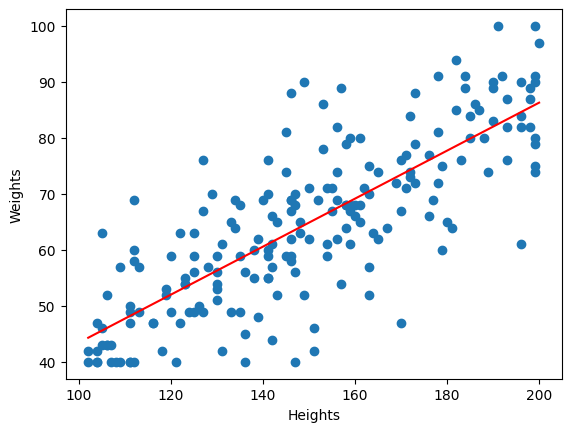

In [124]:
# Plot the regression line
import matplotlib.pyplot as plt

plt.scatter(heights, weights)
plt.plot(heights, a + b * heights, color='red')
plt.xlabel('Heights')
plt.ylabel('Weights')
plt.show()

### 71. Transpose a 5×5 Matrix

Transpose a 5×5 matrix without using libraries.


In [125]:
import numpy as np

In [129]:
def transpose_matrix(matrix):
    n = len(matrix)
    for i in range(n):
        for j in range(i, n):
            matrix[i][j], matrix[j][i] = matrix[j][i], matrix[i][j]


# Random 5x5 matrix
matrix = np.random.randint(1, 10, size=(5, 5))
print("Original Matrix:\n", matrix)

transpose_matrix(matrix)
print("Transposed Matrix:\n", np.array(matrix))

Original Matrix:
 [[6 3 4 5 4]
 [6 8 6 9 6]
 [4 1 3 2 1]
 [8 1 6 2 5]
 [6 3 1 5 3]]
Transposed Matrix:
 [[6 6 4 8 6]
 [3 8 1 1 3]
 [4 6 3 6 1]
 [5 9 2 2 5]
 [4 6 1 5 3]]


### 72. Covariance and Correlation Matrix

Compute covariance and correlation matrices manually.


In [130]:
def sample_mean(x):
    return sum(x) / len(x)

def total(x):
    total = 0
    for i in range(len(x)):
        total += x[i]
    return total

In [131]:
def covariance_matrix(x, y, z):
    cov_matrix = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]
    n = len(x)  # Assume the length of every matrix is similar

    # Find the squared difference of x[i] and mean
    var_x = [(x[i] - sample_mean(x)) ** 2 for i in range(n)]
    var_y = [(y[i] - sample_mean(y)) ** 2 for i in range(n)]
    var_z = [(z[i] - sample_mean(z)) ** 2 for i in range(n)]
    # Cov(X, X); Cov(Y, Y); (Cov(Z, Z))
    cov_x = total(var_x) / (n - 1)
    cov_y = total(var_y) / (n - 1)
    cov_z = total(var_z) / (n - 1)
    # Substitute to the diagonal entries
    cov_matrix[0][0], cov_matrix[1][1], cov_matrix[2][2] = cov_x, cov_y, cov_z

    # Calculate the other entries
    var_xy = [(x[i] - sample_mean(x)) * (y[i] - sample_mean(y)) for i in range(n)]
    cov_xy = total(var_xy) / (n - 1)
    cov_matrix[0][1], cov_matrix[1][0] = cov_xy, cov_xy

    var_xz = [(x[i] - sample_mean(x)) * (z[i] - sample_mean(z)) for i in range(n)]
    cov_xz = total(var_xz) / (n - 1)
    cov_matrix[0][2], cov_matrix[2][0] = cov_xz, cov_xz

    var_yz = [(y[i] - sample_mean(y)) * (z[i] - sample_mean(z)) for i in range(n)]
    cov_yz = total(var_yz) / (n - 1)
    cov_matrix[1][2], cov_matrix[2][1] = cov_yz, cov_yz

    return cov_matrix

In [132]:
def correlation_matrix(cov_matrix):
    # The diagonal entry is 1
    corr_matrix = [[1.0, 0, 0], [0, 1.0, 0], [0, 0, 1.0]]
    # Take the diagonal entries
    cov_x, cov_y, cov_z = cov_matrix[0][0], cov_matrix[1][1], cov_matrix[2][2]
    # Standard Deviation
    sd_x, sd_y, sd_z = cov_x ** 0.5, cov_y ** 0.5, cov_z ** 0.5

    # Calculate the correlation and substitute to the corr_matrix
    cov_xy = cov_matrix[1][0]
    corr_xy = cov_xy / (sd_x * sd_y)
    corr_matrix[1][0], corr_matrix[0][1] = corr_xy, corr_xy

    cov_xz = cov_matrix[2][0]
    corr_xz = cov_xz / (sd_x * sd_z)
    corr_matrix[2][0], corr_matrix[0][2] = corr_xz, corr_xz

    cov_yz = cov_matrix[1][2]
    corr_yz = cov_yz / (sd_y * sd_z)
    corr_matrix[1][2], corr_matrix[2][1] = corr_yz, corr_yz

    return corr_matrix

In [135]:
# Generate random values with numpy
import numpy as np

n = int(input("Enter size: "))
x = np.random.randint(1, 10, n)
y = np.random.randint(1, 10, n)
z = np.random.randint(1, 10, n)

print("X:", x)
print("Y:", y)
print("Z:", z)

cov_matrix = covariance_matrix(x, y, z)
print("Covariance Matrix:\n", np.array(cov_matrix))

corr_matrix = correlation_matrix(cov_matrix)
print("Correlation Matrix:\n", np.array(corr_matrix))

Enter size: 6
X: [9 3 5 6 1 1]
Y: [9 4 7 9 8 6]
Z: [5 1 4 5 1 3]
Covariance Matrix:
 [[9.76666667 3.36666667 4.56666667]
 [3.36666667 3.76666667 2.36666667]
 [4.56666667 2.36666667 3.36666667]]
Correlation Matrix:
 [[1.         0.55507075 0.7963905 ]
 [0.55507075 1.         0.6645971 ]
 [0.7963905  0.6645971  1.        ]]


### 73. U.S. Presidents Lookup

Given a presidential number, determine the corresponding U.S. president.


In [138]:
with open("us president.txt", "r") as file:
    lines = file.readlines()  # Read lines

print("US Presidents")
number = int(input("Enter a number: "))
if number > 47 or number <= 0:
    print("Error: No president found")
else:
    print(lines[number - 1])

US Presidents
Enter a number: 32
32nd President: Franklin D Roosevelt (1882-1945)



### 74. Probability Distributions

Work with Binomial, Poisson, and Normal probability distributions.


In [139]:
from math import factorial, e, sqrt, pi
import numpy as np

In [140]:
def f(y):  # The formula for finding cdf
    return (1 / (sqrt(2 * pi))) * np.exp(-y ** 2 / 2)


def cumulative_density(x):
    lower = -10  # Very small number leads to inaccurate result
    upper = x
    val = np.linspace(upper, lower, 1000)
    I_trapezoids = np.trapz(f(val), val)
    res = abs(I_trapezoids)
    return res

In [141]:
def binomial_dist(n, k, p):  # Binomial Distribution
    C = factorial(n) // (factorial(k) * factorial(n - k))
    res = C * (p ** k) * ((1 - p) ** (n - k))
    return res


def poisson_dist(k, lamb):  # Poisson Distribution
    res = (e ** -lamb) * ((lamb ** k) / factorial(k))
    return res


def normal_dist(a, b, u, sd):  # Normal Distribution
    mui_a = cumulative_density((a - u) / sd)
    mui_b = cumulative_density((b - u) / sd)
    res = mui_b - mui_a
    return res

In [143]:
print("(1): Binomial Distribution X ~ B(n, p)")
print("(2): Poisson Distribution X ~ P(lambda)")
print("(3): Normal Distribution X ~ N(u, sd^2)")

d = int(input("Enter Distribution: "))

if d == 1:
    # n: the total number of trials
    # k: the number of events that satisfy the total trials
    n, k = eval(input("Enter n, k: "))
    # p: The probability in one trial
    p = float(input("Enter p: "))
    print(f"P(X = {k}) = {binomial_dist(n, k, p)}")

elif d == 2:
    k = int(input("Enter k: "))
    lamb = float(input("Enter lambda: "))
    print(f"P(X = {k}) = {poisson_dist(k, lamb)}")

elif d == 3:
    u = float(input("Enter expectation u: "))
    sd = float(input("Enter standard deviation sd: "))
    a, b = eval(input("Enter a, b: "))
    print(f"P({a} \u2264 X \u2264 {b}) = {normal_dist(a, b, u, sd)}")

(1): Binomial Distribution X ~ B(n, p)
(2): Poisson Distribution X ~ P(lambda)
(3): Normal Distribution X ~ N(u, sd^2)
Enter Distribution: 2
Enter k: 12
Enter lambda: 0.45
P(X = 12) = 9.178689621075976e-14


### 75. Parameter Estimation

Estimate confidence intervals for means and proportions.


In [ ]:
import numpy as np

In [144]:
def length(x):
    count = 0
    for i in range(len(x)):
        count += 1
    return count

def sample_mean(x):
    return sum(x) / len(x)

def sample_sd(x):
    mean = sample_mean(x)
    total = 0
    for i in range(len(x)):
        total += (x[i] - mean) ** 2

    return (total / (len(x) - 1)) ** 0.5

In [145]:
def ratio(n, x):  # Estimate point (or ratio)
    # n: total number of samples
    # x: the number of elements that satisfy sample
    f = length(x) / length(n)
    return f

In [146]:
def alpha(conf):  # Confidence = 1 - alpha
    a = 1 - conf
    return a

In [147]:
def score_both_bounds(conf):  # Find Z score
    a = float(alpha(conf) / 2)
    x = round(1 - a, 4)  # Get up to four decimal places
    # Load Table A1 values
    table = {}

    with open("table a1.txt", "r") as file:
        for line in file:
            z_score, prob = map(float, line.strip().split(","))
            table[prob] = z_score

    # Find the closest probability to x
    closest_prob = min(table.keys(), key=lambda p: abs(p - x))
    z = table[closest_prob]

    return z

In [148]:
def score_one_bound(conf):  # Find Z score
    a = float(alpha(conf))
    x = round(1 - a, 4)  # Get up to four decimal places
    # Load Table A1 values
    table = {}

    with open("table a1.txt", "r") as file:
        for line in file:
            z_score, prob = map(float, line.strip().split(","))
            table[prob] = z_score

    # Find the closest probability to x
    closest_prob = min(table.keys(), key=lambda p: abs(p - x))
    z = table[closest_prob]

    return z

In [149]:
def est_mean_both_bounds(n, conf):  # Estimate Interval Mean of both bounds
    number = length(n)
    mean = sample_mean(n)
    sd = sample_sd(n)
    z = score_both_bounds(conf)
    error = z * (sd / (number ** 0.5))
    return error, mean - error, mean + error


def est_mean_bound_left(n, conf):  # Estimate Interval Mean of the left bounds
    number = length(n)
    mean = sample_mean(n)
    sd = sample_sd(n)
    z = score_one_bound(conf)
    error = z * (sd / (number ** 0.5))
    return error, mean - error


def est_mean_bound_right(n, conf):  # Estimate Interval Mean of the right bound
    number = length(n)
    mean = sample_mean(n)
    sd = sample_sd(n)
    z = score_one_bound(conf)
    error = z * (sd / (number ** 0.5))
    return error, mean + error

In [150]:
def est_ratio_both_bounds(n, x, conf):  # Estimate Interval Ratio of both bounds
    f = ratio(n, x)
    number = length(n)
    z = score_both_bounds(conf)
    error = z * ((f * (1 - f) / number) ** 0.5)
    return error, f - error, f + error


def est_ratio_bound_left(n, x, conf):  # Estimate Interval Ratio of the left bounds
    f = ratio(n, x)
    number = length(n)
    z = score_one_bound(conf)
    error = z * ((f * (1 - f) / number) ** 0.5)
    return error, f - error


def est_ratio_bound_right(n, x, conf):  # Estimate Interval Ratio of the right bounds
    f = ratio(n, x)
    number = length(n)
    z = score_one_bound(conf)
    error = z * ((f * (1 - f) / number) ** 0.5)
    return error, f + error

In [151]:
n = int(input("Enter the length of the random sample: "))
sample = np.random.randint(100, 999, n)
print("Sample:\n", sample)

# Get the value require for calculation
confidence = float(input("Enter Confidence level: "))
score_one_bound(confidence)
if confidence < 0 or confidence > 1:
    print("Error: Confidence level is invalid.")

# Calculate Interval Estimation of Mean
x = sample_mean(sample)
e, lower_bound, upper_bound = est_mean_both_bounds(sample, confidence)
e_left, e_right = (est_mean_bound_left(sample, confidence),
                   est_mean_bound_right(sample, confidence))
left_bound, right_bound = e_left[1], e_right[1]

print("x:", x)
print("e:", e)
print("Interval Estimation of Mean:")
print(f"Both Bounds: ({lower_bound}, {upper_bound})")
print(f"Left Bound: ({float("-inf")}, {right_bound})")
print(f"Right Bound: ({left_bound}, {float("-inf")})")

# Get the satisfied number
number_of_event = int(input("Enter a satisfied number: "))
event = []
for k in range(len(sample)):
    # Get the number of events satisfying the satisfied number (use higher case)
    if sample[k] >= number_of_event:
        event.append(sample[k])

# Interval Estimation of Ratio
f = ratio(sample, event)
ef, ef_lower_bound, ef_upper_bound = est_ratio_both_bounds(sample, event, confidence)
ef_left, ef_right = (est_ratio_bound_left(sample, event, confidence),
                     est_ratio_bound_right(sample, event, confidence))
ef_left_bound, ef_right_bound = ef_left[1], ef_right[1]

print(f"There are {len(event)} that satisfy {len(sample)} number of sample")
print("f:", f)
print("e:", e)

print("Interval Estimation of Ratio:")
print(f"Both Bounds: ({ef_lower_bound}, {ef_upper_bound})")
print(f"Left Bound: ({float("-inf")}, {ef_right_bound})")
print(f"Right Bound: ({ef_left_bound}, {float("-inf")})")

Enter the length of the random sample: 100
Sample:
 [174 761 926 675 603 824 737 803 499 125 863 482 492 981 610 221 886 761
 776 267 642 388 523 605 303 418 896 745 514 851 144 298 655 909 749 806
 114 565 159 466 601 678 138 974 314 585 982 235 556 573 115 758 533 237
 982 114 676 174 637 910 675 708 159 512 195 856 251 244 896 567 757 172
 341 504 732 809 507 146 106 223 827 599 877 792 899 859 223 375 768 790
 199 581 332 754 987 748 771 226 647 468]
Enter Confidence level: 0.97
x: 560.7
e: 58.21116031346914
Interval Estimation of Mean:
Both Bounds: (502.4888396865309, 618.9111603134692)
Left Bound: (-inf, 611.1317886586737)
Right Bound: (510.2682113413263, -inf)
Enter a satisfied number: 120
There are 96 that satisfy 100 number of sample
f: 0.96
e: 58.21116031346914
Interval Estimation of Ratio:
Both Bounds: (0.917476858065284, 1.002523141934716)
Left Bound: (-inf, 0.996840325731459)
Right Bound: (0.923159674268541, -inf)
